In [8]:
# Install a library, for example, pandas
!pip install pandas

# After installation, you can import and use the library
import pandas as pd
print(f'pandas version: {pd.__version__}')

pandas version: 2.2.2


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Data Loading**

In [10]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("gokulrajkmv/unemployment-in-india")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'unemployment-in-india' dataset.
Path to dataset files: /kaggle/input/unemployment-in-india


In [11]:
import os

# The 'path' variable from the previous cell contains the directory where the dataset was downloaded.
# We need to specify the full path to the CSV file.
# A common file name for this dataset is 'Unemployment in India.csv'.
file_path = os.path.join(path, 'Unemployment in India.csv')

# Load the CSV file into a pandas DataFrame named 'data'
data = pd.read_csv(file_path)

# Now, you can display the head of the DataFrame
data.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [12]:
data.tail()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
764,NaN,NaN,NaN,NaN,NaN,NaN,NaN
765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
766,NaN,NaN,NaN,NaN,NaN,NaN,NaN
767,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [14]:
data.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


**Data Cleaning**

In [15]:
data.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [16]:
data.columns = data.columns.str.strip()

In [17]:
data.rename(columns={
    'Estimated Unemployment Rate (%)': 'Unemployment_Rate',
    'Estimated Employed': 'Employed',
    'Estimated Labour Participation Rate (%)': 'Labour_Participation_Rate'
}, inplace=True)

In [18]:
data['Date'] = pd.to_datetime(data['Date'])

/tmp/ipykernel_1988/1453708669.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data['Date'] = pd.to_datetime(data['Date'])


In [19]:
print(data.isnull().sum())

Region                       28
Date                         28
Frequency                    28
Unemployment_Rate            28
Employed                     28
Labour_Participation_Rate    28
Area                         28
dtype: int64


In [20]:
data.head()

,Region,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


In [21]:
data.tail()

,Region,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Area
763,NaN,NaT,NaN,NaN,NaN,NaN,NaN
764,NaN,NaT,NaN,NaN,NaN,NaN,NaN
765,NaN,NaT,NaN,NaN,NaN,NaN,NaN
766,NaN,NaT,NaN,NaN,NaN,NaN,NaN
767,NaN,NaT,NaN,NaN,NaN,NaN,NaN


**Exploratory Data Analysis (EDA)**

In [22]:
print(data.describe())

                                Date  Unemployment_Rate      Employed  \
count                            740         740.000000  7.400000e+02   
mean   2019-12-12 18:36:58.378378496          11.787946  7.204460e+06   
min              2019-05-31 00:00:00           0.000000  4.942000e+04   
25%              2019-08-31 00:00:00           4.657500  1.190404e+06   
50%              2019-11-30 00:00:00           8.350000  4.744178e+06   
75%              2020-03-31 00:00:00          15.887500  1.127549e+07   
max              2020-06-30 00:00:00          76.740000  4.577751e+07   
std                              NaN          10.721298  8.087988e+06   

       Labour_Participation_Rate  
count                 740.000000  
mean                   42.630122  
min                    13.330000  
25%                    38.062500  
50%                    41.160000  
75%                    45.505000  
max                    72.570000  
std                     8.111094  


In [23]:
avg_unemployment = data['Unemployment_Rate'].mean()
print("Average Unemployment Rate:", avg_unemployment)

Average Unemployment Rate: 11.787945945945946


In [24]:
highest_region = data.groupby('Region')['Unemployment_Rate'].mean().sort_values(ascending=False)

print(highest_region.head())

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Name: Unemployment_Rate, dtype: float64


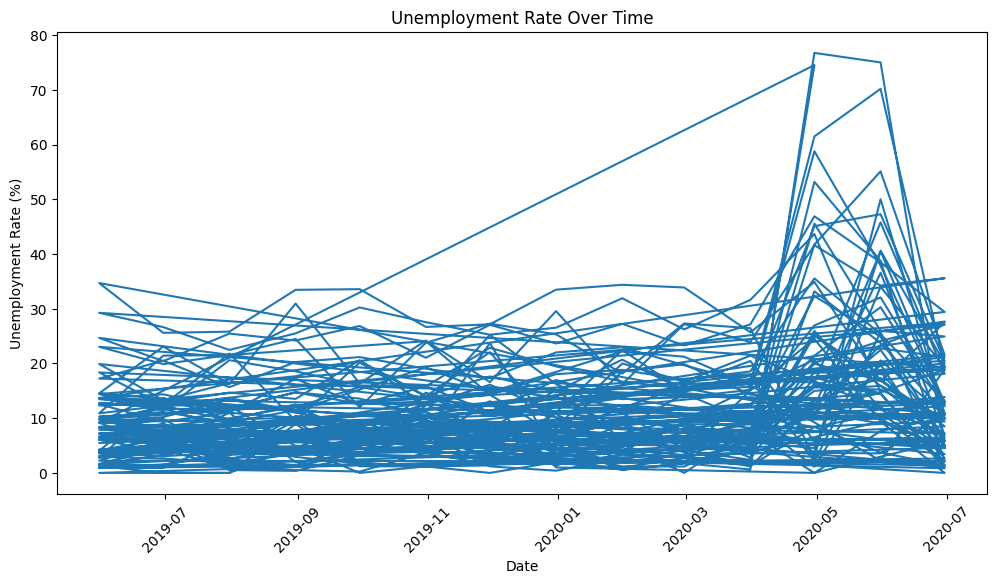

In [25]:
plt.figure(figsize=(12,6))

plt.plot(data['Date'], data['Unemployment_Rate'])

plt.title('Unemployment Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')

plt.xticks(rotation=45)

plt.show()

**COVID-19 Impact Analysis**

In [26]:
covid_period = data[data['Date'] >= '2020-03-01']

In [27]:
before_covid = data[data['Date'] < '2020-03-01']['Unemployment_Rate'].mean()

during_covid = covid_period['Unemployment_Rate'].mean()

print("Before COVID:", before_covid)
print("During COVID:", during_covid)

Before COVID: 9.509533582089553
During COVID: 17.774362745098042


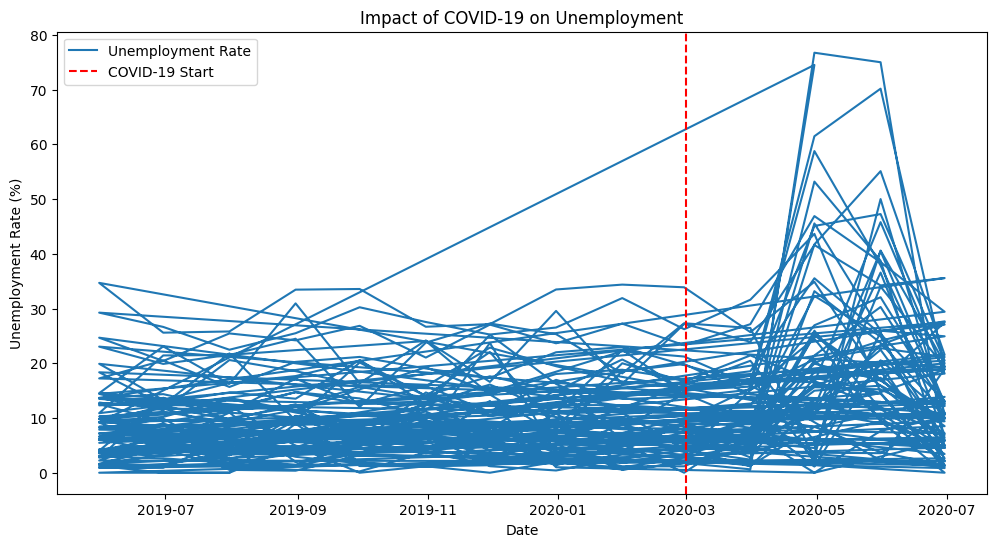

In [28]:
plt.figure(figsize=(12,6))

plt.plot(data['Date'], data['Unemployment_Rate'], label='Unemployment Rate')

plt.axvline(pd.to_datetime('2020-03-01'),
            color='red',
            linestyle='--',
            label='COVID-19 Start')

plt.legend()

plt.title('Impact of COVID-19 on Unemployment')

plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')

plt.show()

**Regional Analysis**

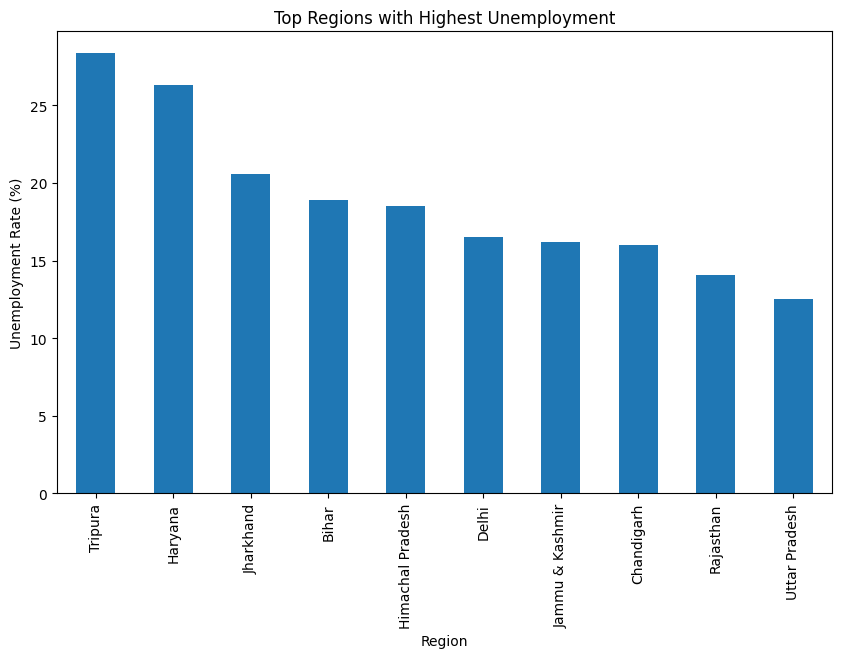

In [29]:
top_regions = data.groupby('Region')['Unemployment_Rate'].mean().sort_values(ascending=False).head(10)

top_regions.plot(kind='bar', figsize=(10,6))

plt.title('Top Regions with Highest Unemployment')
plt.ylabel('Unemployment Rate (%)')

plt.show()

In [30]:
area_analysis = data.groupby('Area')['Unemployment_Rate'].mean()

print(area_analysis)

Area
Rural    10.324791
Urban    13.166614
Name: Unemployment_Rate, dtype: float64


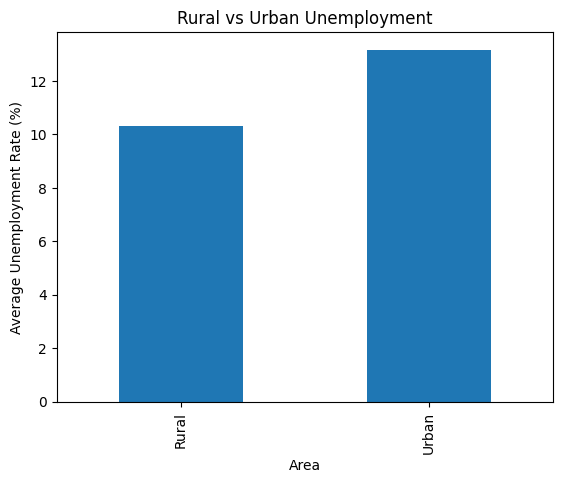

In [31]:
area_analysis.plot(kind='bar')

plt.title('Rural vs Urban Unemployment')
plt.ylabel('Average Unemployment Rate (%)')

plt.show()

**Seasonal Trend Analysis**

In [32]:
data['Month'] = data['Date'].dt.month

In [33]:
monthly_trend = data.groupby('Month')['Unemployment_Rate'].mean()

print(monthly_trend)

Month
1.0      9.950755
2.0      9.964717
3.0     10.700577
4.0     23.641569
5.0     16.646190
6.0     10.553462
7.0      9.033889
8.0      9.637925
9.0      9.051731
10.0     9.900909
11.0     9.868364
12.0     9.497358
Name: Unemployment_Rate, dtype: float64


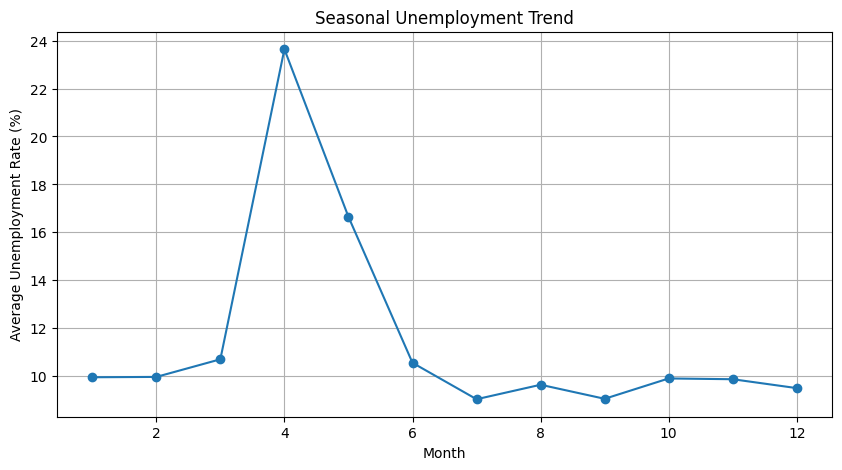

In [34]:
monthly_trend.plot(marker='o', figsize=(10,5))

plt.title('Seasonal Unemployment Trend')

plt.xlabel('Month')
plt.ylabel('Average Unemployment Rate (%)')

plt.grid()

plt.show()

In [35]:
correlation = data[['Unemployment_Rate',
                  'Employed',
                  'Labour_Participation_Rate']].corr()

print(correlation)

                           Unemployment_Rate  Employed  \
Unemployment_Rate                   1.000000 -0.222876   
Employed                           -0.222876  1.000000   
Labour_Participation_Rate           0.002558  0.011300   

                           Labour_Participation_Rate  
Unemployment_Rate                           0.002558  
Employed                                    0.011300  
Labour_Participation_Rate                   1.000000  


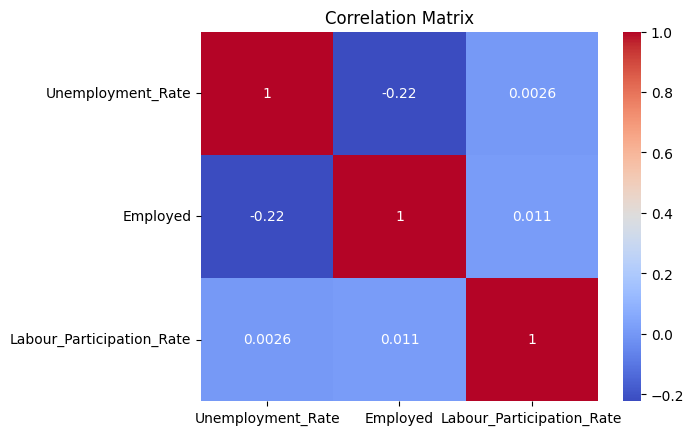

In [36]:

sns.heatmap(correlation,
            annot=True,
            cmap='coolwarm')

plt.title('Correlation Matrix')

plt.show()

In [37]:
# Export the cleaned dataset to a CSV file
data.to_csv('unemployment_cleaned.csv', index=False)
print('Cleaned dataset exported to unemployment_cleaned.csv')

Cleaned dataset exported to unemployment_cleaned.csv


In [38]:
data.to_csv('unemployment_cleaned.csv', index=False)
print('Cleaned dataset exported to unemployment_cleaned.csv')

Cleaned dataset exported to unemployment_cleaned.csv
